# Lab 14

Description of lab:

Understand how to make a simple forecast with an ARIMA model. How to run an ARIMA model with an exogenous variable, and how to create scenarios with exogenous variables. How to model seasonality with ARIMA modeling. 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns


In [4]:
# VISUALS
# Figure size
plt.rcParams['figure.figsize'] = [16,10]

# Text sizes
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelsize']= 12
plt.rcParams['font.size'] = 14

# Colors
plt.rcParams['legend.labelcolor'] = '#ffffff'
plt.rcParams['xtick.labelcolor'] = '#ffffff'
plt.rcParams['ytick.labelcolor'] = '#ffffff'
plt.rcParams['axes.labelcolor'] = '#ffffff'
plt.rcParams['axes.titlecolor'] = '#ffffff'
plt.rcParams['axes.edgecolor'] = '#ffffff'
plt.rcParams['xtick.color'] = '#ffffff'
plt.rcParams['ytick.color'] = '#ffffff'
plt.rcParams['figure.facecolor'] = '#1f1f1f'
plt.rcParams['axes.facecolor'] = '#1f1f1f'

# Graph colors
from cycler import cycler

diverse = ['#1f78b4', '#33a02c', '#e31a1c', '#ff7f00', '#6a3d9a', '#b15928', '#a6cee3', '#b2df8a', '#fb9a99']
greens = ['#2ca02c', '#4daf4a', '#45a05a', '#60bd68', '#5cb85c', '#6ba981', '#75bb6f', '#6dae64', '#4c9a5f']
blues = ['#1f78b4', '#377eb8', '#3182bd', '#4292c6', '#5aaed6', '#6baed6', '#7ba3df', '#92b3e4', '#a6bddb']
reds = ['#e41a1c', '#d73027', '#a50026', '#f46d43', '#d73027', '#fdae61', '#fee08b', '#fee08b', '#d73027']

plt.rcParams['axes.prop_cycle'] = cycler(color = diverse)

# Display max columns, pandas dataframes
pd.set_option('display.max_columns', None) 

### Power prices and ETS prices

In [14]:
ets = pd.read_csv("http://jmaurit.github.io/analytics/labs/data/eua-price.csv")
ets.columns = ['date', 'ets_price']

In [15]:
elspot = pd.read_csv("http://jmaurit.github.io/norwayeconomy/data_series/elspot.csv")

In [16]:
elspot['date'] = pd.to_datetime(elspot['date'])
ets['date'] = pd.to_datetime(ets['date'])

In [17]:
ets['month'] = ets['date'].dt.month
ets['year'] = ets['date'].dt.year
ets_monthly = ets.groupby(['year', 'month'])['ets_price'].aggregate('mean')
ets_monthly = ets_monthly.reset_index()
ets_monthly['day'] = 1
ets_monthly['date'] = pd.to_datetime(ets_monthly[['year', 'month', 'day']])

In [18]:
ets_monthly

,year,month,ets_price,day,date
0,2008,4,25.855625,1,2008-04-01
1,2008,5,26.805500,1,2008-05-01
2,2008,6,29.095600,1,2008-06-01
3,2008,7,27.194500,1,2008-07-01
4,2008,8,25.712000,1,2008-08-01
...,...,...,...,...,...
137,2019,10,24.930500,1,2019-10-01
138,2019,11,24.525000,1,2019-11-01
139,2019,12,25.259900,1,2019-12-01
140,2020,1,24.401000,1,2020-01-01


In [19]:
ets_monthly = ets_monthly.loc[:, ['date', 'ets_price']].copy()

In [20]:
dkprices = elspot.loc[:, ['date', 'DK1', 'DK2']]
power_DF = dkprices.merge(ets_monthly, how = 'left', on = 'date')

In [21]:
power_DF

,date,DK1,DK2,ets_price
0,2000-01-01,1779,NaN,NaN
1,2000-02-01,1431,NaN,NaN
2,2000-03-01,1453,NaN,NaN
3,2000-04-01,1593,NaN,NaN
4,2000-05-01,1680,NaN,NaN
...,...,...,...,...
223,2018-08-01,5569,5684.0,19.0950
224,2018-09-01,4989,5179.0,21.4410
225,2018-10-01,4748,5090.0,19.3204
226,2018-11-01,5404,5468.0,19.5105


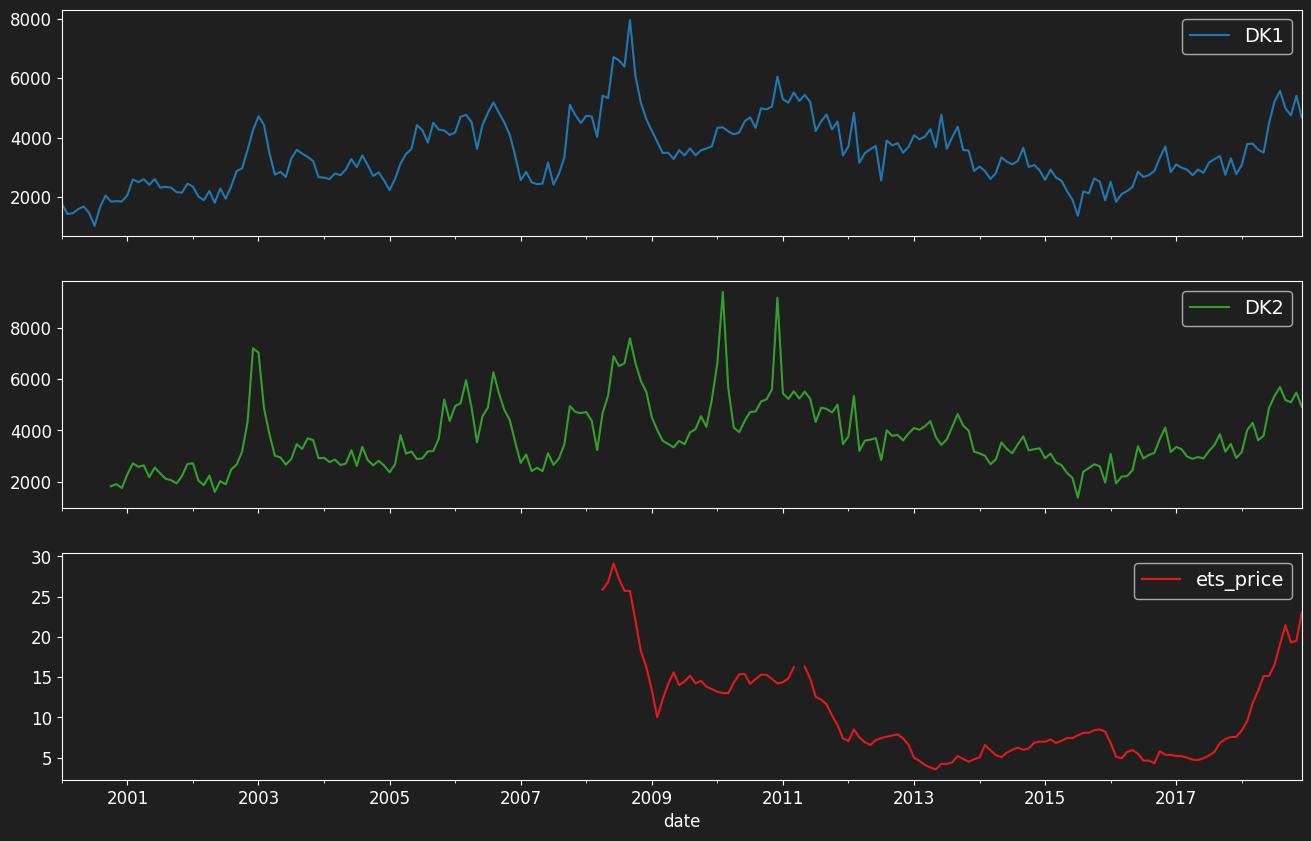

In [22]:
power_DF.set_index('date').plot(subplots = True)
plt.show()

In [23]:
# Downscaling power prices for it to be similar to the ets prices. Dividing by 1 000:
power_DF['DK1'] = power_DF['DK1'] / 1000
power_DF['DK2'] = power_DF['DK2'] / 1000

### Forecasting ARIMA models

### Forecasts based on ARIMA models

##### Adding an exogenous regressor to the model

##### Seasonality